# Классификация текста 
## Ссылки

https://www.youtube.com/watch?v=AwdawjHJstU - Классификация текста | Обработка естественного языка</br>
https://www.youtube.com/watch?v=55Iyei3bkKk&list=PLtPJ9lKvJ4ohZpMV9Ml-DPtMSXPFNl6Sz</br>

https://www.youtube.com/watch?v=-2O0ODmnw1o - NLP cookbook: анализируем тексты на Python с минимальными знаниями о машинном обучении

# 0. Импорты

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import stopwords
import string
import re
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


# 1. Загрузка датасета

In [2]:
df = pd.read_json("data/data.txt", lines=True)
df

,text,tags,schema_name,table_name
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710
...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876


In [3]:
final_df = df.copy()

# Мультиклассовая классификация на основе имён таблиц

In [4]:
final_df['full_table_name'] = final_df['schema_name'] + '.' + final_df['table_name']
# final_df['class_name'] =  final_df['tags'].apply(lambda x: '/'.join(x))
codes, class_unique_names = pd.factorize(final_df['full_table_name']) # для Multiclass классификации на основе имени таблицы
# codes - идентификаторы, unique_names - названия классов
final_df['class_id'] = codes
# также сделать дял multilable classification. Если нет тегов, то брать имя таблицы
final_df

,text,tags,schema_name,table_name,full_table_name,class_id
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,_46379._47923,0
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1
...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20


# Анализ датасета
## Распределение данных по классам

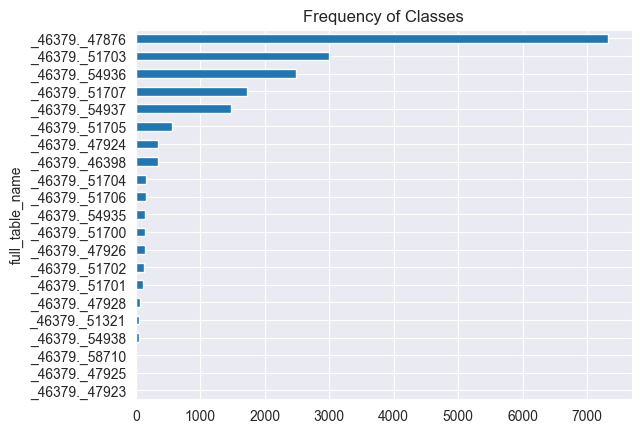

In [5]:
# узнаем кол-во примеров в каждом классе
final_df["full_table_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

In [6]:
final_df["full_table_name"].value_counts(ascending=True)

full_table_name
_46379._47923       1
_46379._47925       1
_46379._58710       6
_46379._54938      46
_46379._51321      50
_46379._47928      64
_46379._51701     108
_46379._51702     133
_46379._47926     144
_46379._51700     146
_46379._54935     148
_46379._51706     156
_46379._51704     164
_46379._46398     342
_46379._47924     343
_46379._51705     558
_46379._54937    1483
_46379._51707    1727
_46379._54936    2485
_46379._51703    2992
_46379._47876    7327
Name: count, dtype: int64

## Распределение кол-ва токенов в классах

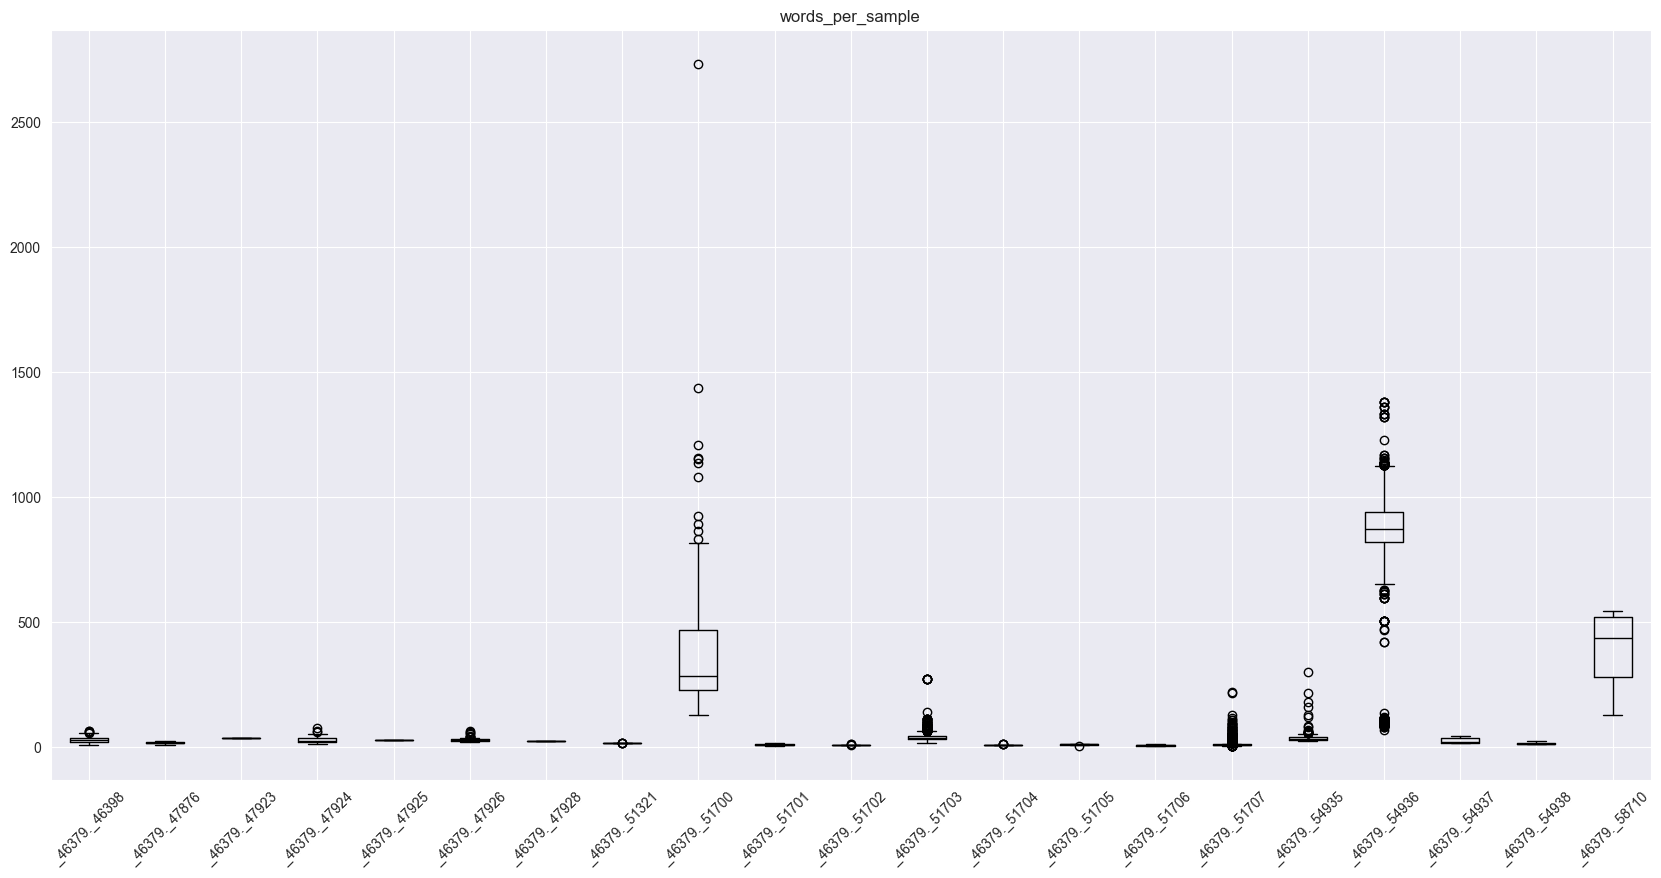

In [7]:
# кол-во слов в каждом классе
final_df["words_per_sample"] = final_df["text"].str.split().apply(len)
final_df.boxplot("words_per_sample", by="full_table_name", grid=True,
showfliers=True, color="black", figsize=(20, 10), rot=45)
plt.suptitle("")
plt.xlabel("")
plt.show()


# Формирование датафрейма. Предобработка данных. Получение эмбедингов.Общие стандартные шаги для начала работы

Итоговые рекомендации:
Прекратите удалять стоп-words и, возможно, прекратите приводить к нижнему регистру. Просто проведите базовую очистку: удалите лишние пробелы, спецсимволы, HTML-теги, если они есть, и т.д.

Никакой дополнительной токенизации не нужно. Просто передавайте строку в model.encode(). Доверяйте встроенному пайплайну SentenceTransformer. Он отлично спроектирован и сам выполнит всю необходимую низкоуровневую работу. Ваша задача — подать на вход качественный, связный текст

In [8]:
# Загрузка модели Sentence-BERT (выбираем multilingual версию)
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

In [9]:
# Загрузка стоп-слов (один раз при старте)
# nltk.download('stopwords')
# stop_words = set(stopwords.words('russian')) # Загрузка стоп-слов (один раз при старте)

In [10]:
# Функция для очистки текста
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Удаление URL
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)
    # Удаление цифр и специальных символов
    text = re.sub(r'\d+', ' ', text)
    # Удаление пунктуации
    # text = text.translate(str.maketrans('', '', string.punctuation))
    translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    text = text.translate(translator)
    # Приведение к нижнему регистру (не всегда обязательно, возможно ухудшит качество)
    text = text.lower()
    # Удаление стоп-слов (не всегда  обязательно, возможно ухудшит качество)
    # stop_words = set(stopwords.words('russian'))
    words = text.split()
    # words = [word for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

In [11]:
# Функция для получения имени сервиса. Именем сервиса является номер на 2-ой позиции в списке тегов
def get_service_name(list_of_tags):
    # если недостаточное кол-во тегов -> нет сервиса -> возвращаем пустую строку
    if len(list_of_tags) < 2:
        return ''
    service_name = list_of_tags[1]
    return service_name

In [12]:
# Функция для получения осмысленного имени таблицы. Именем таблицы является последний номер в списке тегов
def get_table_info_name(tags, table_name):

    # если недостаточное кол-во тегов -> нет сервиса -> возвращаем пустую строку
    if len(tags) == 0:
        # return ''
        return table_name
    table_info_name = tags[-1] # получаем последнюю строку
    return table_info_name

In [13]:
# Функция для обработки чанка с очисткой текста
def process_chunk(chunk):
    """Генерирует эмбеддинги для чанка с предварительной очисткой"""
    # Очищаем тексты
    cleaned_texts = chunk['text'].apply(clean_text).tolist()
    # получаем имена сервисов
    service_names = chunk['tags'].apply(get_service_name).tolist()
    # получаем осмысленное имя таблицы
    table_info_name = chunk.apply(lambda row: get_table_info_name(row['tags'], row['full_table_name']), axis=1).tolist()
    # chunk.apply(lambda row: get_table_info_name(row))
    # table_info_name = chunk.apply(get_table_info_name).tolist()
    # Генерируем эмбеддинги для всех текстов в чанке
    embeddings = model.encode(cleaned_texts, 
                            show_progress_bar=False,
                            convert_to_numpy=True)
    
    # Добавляем результаты в чанк
    chunk['cleaned_text'] = cleaned_texts
    chunk['embeddings'] = list(embeddings)
    chunk['service_name'] = service_names
    chunk['table_info_name'] = table_info_name
    return chunk

In [14]:
final_df

,text,tags,schema_name,table_name,full_table_name,class_id,words_per_sample
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,_46379._47923,0,39
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,130
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,372
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,252
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,504
...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,13
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,17


In [15]:
# Размер чанка (подбирайте под ваши ресурсы)
CHUNK_SIZE = 1000  
# Инициализация прогресс-бара
pbar = tqdm(total=len(final_df), desc="Обработка датафрейма")
# Обработка по чанкам
results = []
for i in range(0, len(final_df), CHUNK_SIZE):
    chunk = final_df.iloc[i:i + CHUNK_SIZE].copy()
    processed_chunk = process_chunk(chunk)
    results.append(processed_chunk)
    pbar.update(len(chunk))
pbar.close()

# Сборка финального датафрейма
final_df = pd.concat(results, ignore_index=True)

Обработка датафрейма: 100%|██████████| 18424/18424 [00:14<00:00, 1252.44it/s]


In [16]:
final_df

,text,tags,schema_name,table_name,full_table_name,class_id,words_per_sample,cleaned_text,embeddings,service_name,table_info_name
0,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47923,_46379._47923,0,39,часть территории национального парка лосиный о...,"[0.3547967, 0.16676068, 0.07977914, -0.0005325...",440 Особо охраняемые природные территории,Границы ООПТ
1,"1 1 1 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,130,часть территории национального парка лосиный о...,"[0.22239774, 0.15734524, 0.013664918, -0.04089...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
2,"2 2 2 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,372,часть территории национального парка лосиный о...,"[0.28809375, 0.14398257, 0.04981663, -0.006072...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
3,"3 3 3 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,252,часть территории национального парка лосиный о...,"[0.28809375, 0.14398257, 0.04981663, -0.006072...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
4,"4 4 4 Часть территории национального парка ""Ло...","[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_58710,_46379._58710,1,504,часть территории национального парка лосиный о...,"[0.36440247, 0.12335314, 0.059311002, -0.05470...",440 Особо охраняемые природные территории,"Зонирование, Режимы охраны и использования ООПТ"
...,...,...,...,...,...,...,...,...,...,...,...
18419,996 996 982 20231117_110117.jpg 2023-11-17 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,13,jpg photo зелао уч комплексный заказник зелено...,"[0.15561336, 0.32526222, 0.0925827, 0.00283530...",440 Особо охраняемые природные территории,Фотофиксация
18420,997 997 983 20231121_100442.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22,jpg photo юзао и юао пип битцевский лес участо...,"[0.0332909, 0.2387227, 0.2250042, 0.11981269, ...",440 Особо охраняемые природные территории,Фотофиксация
18421,998 998 984 20231121_095847.jpg 2023-11-21 00:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,22,jpg photo юзао и юао пип битцевский лес участо...,"[0.0332909, 0.2387227, 0.2250042, 0.11981269, ...",440 Особо охраняемые природные территории,Фотофиксация
18422,99 99 101 117 4.jpg 2023-11-16 00:00:00+00 13:...,"[МКА. Геоданные, 440 Особо охраняемые природны...",_46379,_47876,_46379._47876,20,17,jpg photo зелао уч комплексный заказник зелено...,"[0.15561336, 0.32526222, 0.0925827, 0.00283530...",440 Особо охраняемые природные территории,Фотофиксация


# Класификация по таблицам

In [17]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [18]:
final_df['class_id'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])

In [19]:
final_df['class_id']

0         0
1         1
2         1
3         1
4         1
         ..
18419    20
18420    20
18421    20
18422    20
18423    20
Name: class_id, Length: 18424, dtype: int64

In [20]:
# Проблема в том, что final_df['embeddings'] содержит массивы или списки, а не плоские числовые значения. Вот как это исправить:
X = final_df['embeddings']
# Преобразуем список/серию эмбеддингов в 2D numpy array
X = np.vstack(X.values)  # или np.array(X.tolist())
y = final_df['class_id'].values


In [21]:
# Разделение на train/test. Не работает т.к. в некоторых классах могут быть только один сэмпл
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
from sklearn.utils import shuffle
def manual_stratified_split(X, y, test_size=0.2, random_state=42):
    """
    Ручное стратифицированное разделение для данных с редкими классами
    Учитывает, что в некоторых классах может быть один сэмпл
    """
    
    unique_classes = np.unique(y)
    X_train, X_test, y_train, y_test = [], [], [], []
    
    for cls in unique_classes:
        # Выбираем samples текущего класса
        mask = y == cls
        X_cls = X[mask]
        y_cls = y[mask]
        
        n_samples = len(X_cls)
        
        if n_samples == 1:
            # Если только 1 sample - всегда в train
            X_train.append(X_cls)
            y_train.append(y_cls)
            # и в тест тоже
            X_test.append(X_cls)
            y_test.append(y_cls)
        else:
            # Разделяем класс
            n_test = max(1, int(n_samples * test_size))  # минимум 1 в test
            n_train = n_samples - n_test
            
            # Перемешиваем
            X_cls, y_cls = shuffle(X_cls, y_cls, random_state=random_state)
            
            X_train.append(X_cls[:n_train])
            X_test.append(X_cls[n_train:n_train + n_test])
            y_train.append(y_cls[:n_train])
            y_test.append(y_cls[n_train:n_train + n_test])
    
    # Объединяем результаты
    X_train = np.vstack(X_train) if hasattr(X[0], 'shape') else np.concatenate(X_train)
    X_test = np.vstack(X_test) if hasattr(X[0], 'shape') else np.concatenate(X_test)
    y_train = np.concatenate(y_train)
    y_test = np.concatenate(y_test)
    
    return X_train, X_test, y_train, y_test

# Использование
X_train, X_test, y_train, y_test = manual_stratified_split(X, y, test_size=0.2)

In [23]:
# Обучение классификатора
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(X_train, y_train)
    
# Предсказание и оценка
y_pred = classifier.predict(X_test)
    
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

Accuracy: 0.9980967917346384

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00         1
           1       1.00      0.00      0.00         1
           2       1.00      0.00      0.00         1
           3       1.00      1.00      1.00        12
           4       1.00      0.97      0.98        29
           5       1.00      1.00      1.00       497
           6       1.00      1.00      1.00       296
           7       0.90      1.00      0.95         9
           8       1.00      1.00      1.00        32
           9       1.00      0.95      0.98        21
          10       0.97      1.00      0.98        29
          11       1.00      1.00      1.00        26
          12       1.00      1.00      1.00       598
          13       1.00      1.00      1.00        31
          14       1.00      1.00      1.00       111
          15       1.00      1.00      1.00        28
          16       1.00     

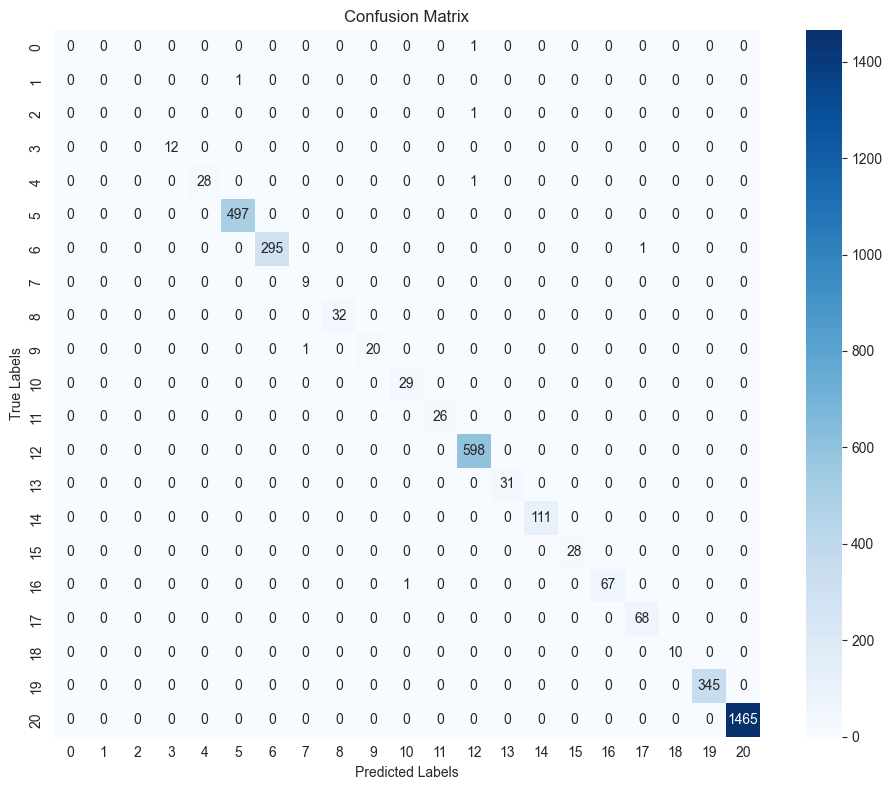

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(10, 8))
# Вычисляем confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            cbar=True,
            # xticklabels=class_unique_names,
            # yticklabels=class_unique_names,
            square=True)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

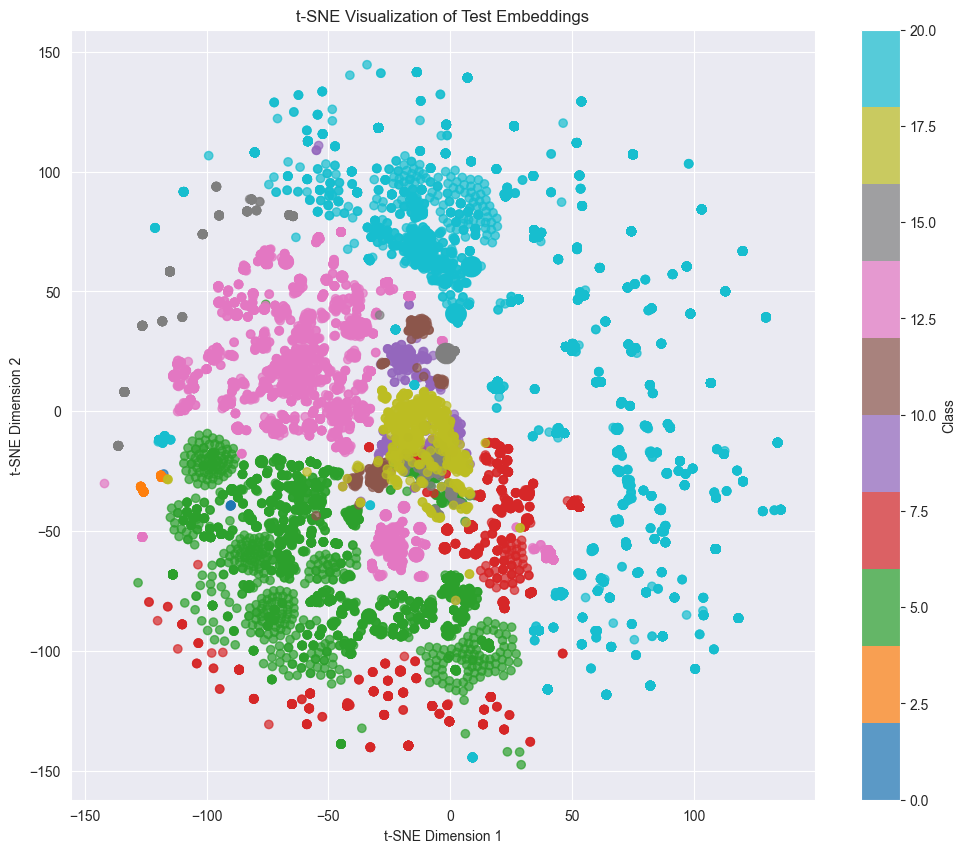

In [25]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Уменьшаем размерность для визуализации
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Class')
plt.title('t-SNE Visualization of Test Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [26]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

In [27]:
import plotly.express as px

# Подготовка данных для визуализации
df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'classes': final_df['class_id'],
    'full_table_name': final_df['full_table_name']
})
# Интерактивная визуализация
fig = px.scatter(
    df,
    x='x',
    y='y',
    color='classes',
    hover_data=['full_table_name'],
    title='t-SNE Visualization of Test Embeddings',
    width=1000,
    height=600
)
fig.update_traces(marker=dict(size=12, opacity=0.7))
fig.show()

# DummyClassifier - проверяем дейтсвительно ли полученная модеоь справляется лучше, чем случайный выбор по выбранной стратегии

In [28]:
from sklearn.dummy import DummyClassifier
# Создаем несколько стратегий dummy classifier
strategies = ['stratified', 'most_frequent', 'prior', 'uniform', 'constant']

# strategy = 'most_frequent'
results = []
for strategy in strategies:
    if strategy == 'constant':
        # Для constant стратегии нужно указать constant value
        dummy = DummyClassifier(strategy=strategy, constant=y_train[0])
    else:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        
    # Обучаем и предсказываем
    dummy.fit(X_train, y_train)
    y_pred_dummy = dummy.predict(X_test)
        
    # Вычисляем accuracy
    accuracy = accuracy_score(y_test, y_pred_dummy)
        
    results.append({
        'strategy': strategy,
        'accuracy': accuracy,
        'predictions': y_pred_dummy
        })
        
    print(f"Dummy classifier {strategy}: Accuracy = {accuracy:.4f}")

# Сравниваем с вашей моделью
real_model_accuracy = accuracy_score(y_test, y_pred)
print(f"Real classifier: Accuracy = {real_model_accuracy:.4f}")

Dummy classifier stratified: Accuracy = 0.2200
Dummy classifier most_frequent: Accuracy = 0.3983
Dummy classifier prior: Accuracy = 0.3983
Dummy classifier uniform: Accuracy = 0.0484
Dummy classifier constant: Accuracy = 0.0003
Real classifier: Accuracy = 0.9981


In [29]:
# предсказание
test_text = '1 1 1 Часть территории национального парка \"Лосиный остров\", расположенная в границах города Москвы ППМ № 769-ПП от 11.04.2025 ИК Зона охраны объектов культурного наследия (памятников истории и культуры) народов Российской Федерации 3.1. Коммунальное обслуживание. 3.9. Обеспечение научной деятельности. 5.2. Природно-познавательный туризм. 9.0. Деятельность по особой охране и изучению природы. 9.1. Охрана природных территорий. 9.3. Историко-культурная деятельность. 12.0. Земельные участки (территории) общего пользования - выполнение инженерно-геологических изысканий; - строительство и реконструкция объектов, сооружений и инженерно-технических коммуникаций, связанных с охраной и использованием Национального парка в границах города Москвы, в границах участков размещения объектов капитального строительства; - поддержание в исправном состоянии существующей дорожно-тропиночной сети, сетей наружного освещения, элементов благоустройства; - создание и обустройство зон с информационными площадками Ограничения определяются законодательством Российской Федерации и города Москвы об объектах культурного наследия. 12.032815458365 2323.37880952977 120328.1495391'
cleaned_test_text = clean_text(test_text)
encoded_test_text = model.encode(cleaned_test_text)
# encoded_test_text = np.vstack(encoded_test_text.values)  # или np.array(X.tolist())
test_result = classifier.predict([encoded_test_text])
test_proba = classifier.predict_proba([encoded_test_text])
test_proba

array([[3.73672236e-03, 2.18003637e-01, 3.60661943e-03, 3.59312159e-02,
        1.19473579e-02, 5.24250172e-01, 1.11111475e-04, 1.51032332e-03,
        1.24093461e-04, 2.75780031e-04, 3.39995884e-02, 5.84854658e-04,
        6.90796802e-02, 5.42104170e-04, 9.52830625e-04, 5.71911600e-04,
        5.36895125e-02, 8.23296275e-03, 3.14267739e-02, 9.35965719e-04,
        4.86782117e-04]])

In [30]:
len(class_unique_names)

21

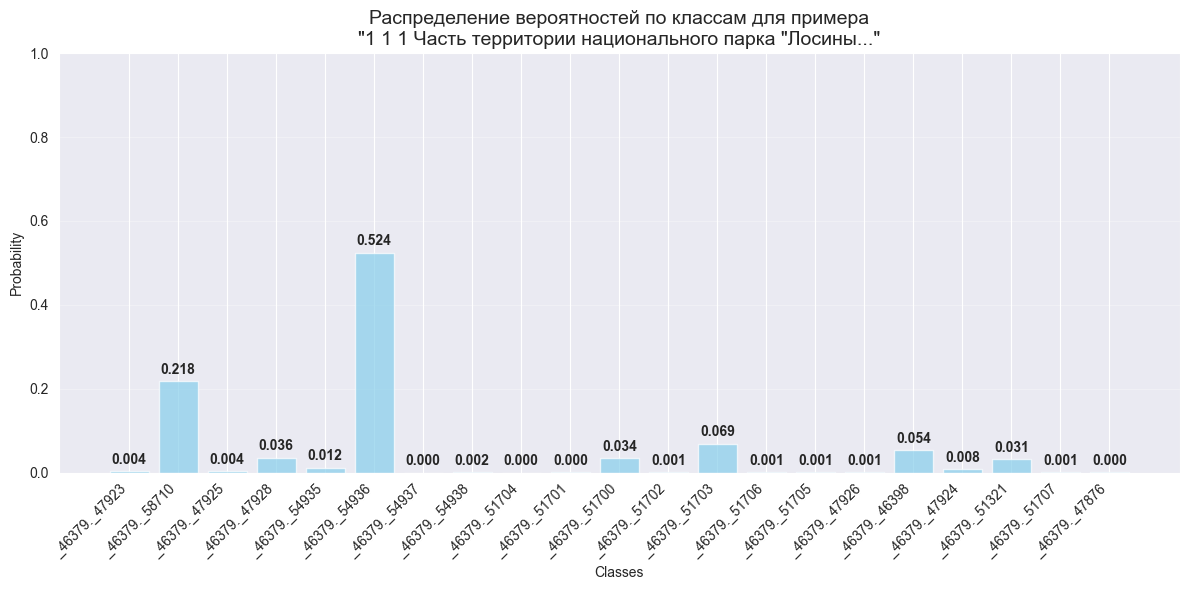

In [31]:
# Создаем bar plot
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(class_unique_names)), test_proba[0], color='skyblue', alpha=0.7)

plt.title(f'Распределение вероятностей по классам для примера\n"{test_text[:50]}..."', fontsize=14)
plt.xlabel('Classes')
plt.ylabel('Probability')
plt.xticks(range(len(class_unique_names)), class_unique_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (bar, prob) in enumerate(zip(bars, test_proba[0])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{prob:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('single_sample_proba.png', dpi=300, bbox_inches='tight')
plt.show()

# Применим GridSearchCV для подбора оптимальных параметров

In [32]:
# from sklearn.model_selection import GridSearchCV
# # Best practice для начала
# param_grid = {
#     'C': [0.1, 1, 10, 100],
#     'class_weight': [None, 'balanced'],
#     'solver': ['lbfgs', 'liblinear']
# }
# grid_search = GridSearchCV(
#     LogisticRegression(max_iter=1000, random_state=42),
#     param_grid,
#     cv=5,
#     scoring='accuracy'
# )
# grid_search.fit(X_train, y_train)

In [33]:
# print("Лучшие параметры:", grid_search.best_params_)
# print("Лучшая accuracy:", grid_search.best_score_)
# 
# # Используем лучшую модель
# best_classifier = grid_search.best_estimator_

# Альтернативные варианты </br>
1. LinearSVC (линейный SVM) </br>
2. Random Forest <br>
3. Gradient Boosting (XGBoost/LightGBM/CatBoost) </br>
4. MLP (нейронная сеть) </br>
5. Ансамбли </br>

Визуализация сравнения моделей </br>


In [34]:
# pip install xgboost
# from xgboost import XGBClassifier
# from sklearn.svm import LinearSVC
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.neural_network import MLPClassifier
# from sklearn.ensemble import VotingClassifier
# from sklearn.model_selection import cross_validate
# from sklearn.model_selection import cross_validate
# from sklearn.model_selection import cross_val_score

In [35]:
# Альтернативные модели
# models = {
#     'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
#     'LinearSVC': LinearSVC(random_state=42),
#     'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
#     'XGBoost': XGBClassifier(use_label_encoder=False, random_state=42)
# }
# # Ансамбль нескольких моделей
# ensemble = VotingClassifier(
#     estimators=[
#         ('logreg', LogisticRegression(max_iter=1000, random_state=42)),
#         ('svm', LinearSVC(random_state=42)),
#         ('rf', RandomForestClassifier(n_estimators=50, random_state=42))
#     ],
#     voting='soft'  # для вероятностей
# )

# Multilable classification по структуре в orbis (тегам). Если нет тегов, то используем имя таблицы

In [36]:
# подготовим датасет
# определим список уникальных тегов
tags = [item for item in final_df['tags']]
unique_tags  = list(set(tag for sublist in tags for tag in sublist))
unique_tags

['Архив',
 'Достопримечательности',
 'МКА. Геоданные',
 'Гидрология (площадные объекты)',
 'Фотофиксация',
 'Зонирование, Режимы охраны и использования ООПТ (архив)',
 'ООПТ (точки)',
 'Границы ООПТ',
 'Территории ООПТ по ППМ',
 'Гидрология (линейные объекты)',
 'Границы ООПТ (архив)',
 'Рельеф',
 'Проверка ООПТ',
 'Предельные параметры разрешенного строительства, реконструкции объектов капитального строительства на территории ООПТ',
 'Зонирование, Режимы охраны и использования ООПТ',
 'Охранные зоны ООПТ (архив)',
 '440 Особо охраняемые природные территории',
 'Охранные зоны ООПТ',
 'Предельные параметры разрешенного строительства, реконструкции объектов капитального строительства на территории ООПТ (архив)',
 'Кадастр ООПТ',
 'Почва',
 'Флора и фауна',
 'Земельные участки',
 'ООПТ в соответствии с Законом города Москвы № 37 от 06.07.2005']

In [37]:
empty_tags_df = final_df[final_df['tags'].apply(lambda x: isinstance(x, list) and len(x) == 0)]
unique_table_names_with_empty_tags = empty_tags_df['full_table_name'].unique().tolist()

In [38]:
unique_labels = unique_tags + unique_table_names_with_empty_tags
unique_labels

['Архив',
 'Достопримечательности',
 'МКА. Геоданные',
 'Гидрология (площадные объекты)',
 'Фотофиксация',
 'Зонирование, Режимы охраны и использования ООПТ (архив)',
 'ООПТ (точки)',
 'Границы ООПТ',
 'Территории ООПТ по ППМ',
 'Гидрология (линейные объекты)',
 'Границы ООПТ (архив)',
 'Рельеф',
 'Проверка ООПТ',
 'Предельные параметры разрешенного строительства, реконструкции объектов капитального строительства на территории ООПТ',
 'Зонирование, Режимы охраны и использования ООПТ',
 'Охранные зоны ООПТ (архив)',
 '440 Особо охраняемые природные территории',
 'Охранные зоны ООПТ',
 'Предельные параметры разрешенного строительства, реконструкции объектов капитального строительства на территории ООПТ (архив)',
 'Кадастр ООПТ',
 'Почва',
 'Флора и фауна',
 'Земельные участки',
 'ООПТ в соответствии с Законом города Москвы № 37 от 06.07.2005']

In [39]:
label_codes, labels_unique_names = pd.factorize(np.array(unique_labels))
label_codes

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [40]:
labels_codes_maping = dict(zip(labels_unique_names, label_codes))
labels_codes_maping

{np.str_('Архив'): np.int64(0),
 np.str_('Достопримечательности'): np.int64(1),
 np.str_('МКА. Геоданные'): np.int64(2),
 np.str_('Гидрология (площадные объекты)'): np.int64(3),
 np.str_('Фотофиксация'): np.int64(4),
 np.str_('Зонирование, Режимы охраны и использования ООПТ (архив)'): np.int64(5),
 np.str_('ООПТ (точки)'): np.int64(6),
 np.str_('Границы ООПТ'): np.int64(7),
 np.str_('Территории ООПТ по ППМ'): np.int64(8),
 np.str_('Гидрология (линейные объекты)'): np.int64(9),
 np.str_('Границы ООПТ (архив)'): np.int64(10),
 np.str_('Рельеф'): np.int64(11),
 np.str_('Проверка ООПТ'): np.int64(12),
 np.str_('Предельные параметры разрешенного строительства, реконструкции объектов капитального строительства на территории ООПТ'): np.int64(13),
 np.str_('Зонирование, Режимы охраны и использования ООПТ'): np.int64(14),
 np.str_('Охранные зоны ООПТ (архив)'): np.int64(15),
 np.str_('440 Особо охраняемые природные территории'): np.int64(16),
 np.str_('Охранные зоны ООПТ'): np.int64(17),
 np.st

In [41]:
final_df['labels'] = None
final_df

text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 1 1 1 Часть территории национального п

In [42]:
def add_multilabel_ids(row):
    if len(row['tags']) == 0:
        return [row['full_table_name']]
    else:
        return row['tags']

final_df['labels'] = final_df.apply(lambda row: add_multilabel_ids(row),axis=1)
final_df

text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 1 1 1 Часть территории национального п

In [77]:
from sklearn.preprocessing import MultiLabelBinarizer
# Создаем бинаризатор
mlb = MultiLabelBinarizer()
# Преобразуем labels в бинарную матрицу
y = mlb.fit_transform(final_df['labels'])
y

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 0, ..., 0, 0, 1],
       [1, 1, 0, ..., 0, 0, 1],
       [1, 1, 0, ..., 0, 0, 1]])

In [78]:
# Разделяем данные
# X_train, X_test, y_train, y_test = train_test_split(
#     np.vstack(final_df['embeddings'].values),  # ваши эмбеддинги
#     y,
#     test_size=0.2,
#     random_state=42
# )

In [79]:
# Разделяем данные
X = np.vstack(final_df['embeddings'].values)
# X_train, X_test, y_train, y_test = manual_stratified_split(X, y, test_size=0.2)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [80]:
# Установите: pip install iterative-stratification
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
# Создаем стратифицированный split
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1, 
    test_size=0.2, 
    random_state=42
)

for train_index, test_index in msss.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

print("Размеры после стратифицированного разделения:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Размеры после стратифицированного разделения:
X_train: (14739, 384), y_train: (14739, 24)
X_test: (3685, 384), y_test: (3685, 24)


In [81]:
# Проверяем уникальные классы в y_train и y_test
print("Уникальные классы в y_train:", np.unique(y_train))
print("Уникальные классы в y_test:", np.unique(y_test))

Уникальные классы в y_train: [0 1]
Уникальные классы в y_test: [0 1]


In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

# RandomForest более устойчив к несбалансированным данным
classifier = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    n_jobs=-1
)

# Обучаем модель
classifier.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(class_weight='balanced',
                                                       random_state=42),
                      n_jobs=-1)

In [83]:
# Предсказание
y_pred = classifier.predict(X_test)
y_pred_proba = classifier.predict_proba(X_test)

# Отчет классификации
print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))

                                                                                                                               precision    recall  f1-score   support

                                                                                    440 Особо охраняемые природные территории       1.00      1.00      1.00      3685
                                                                                                                        Архив       1.00      1.00      1.00      3671
                                                                                                Гидрология (линейные объекты)       1.00      0.74      0.85        27
                                                                                               Гидрология (площадные объекты)       1.00      0.91      0.95        33
                                                                                                                 Границы ООПТ       0.00      0.00      0.00        

(array([[   0,    0],
       [   0, 3685]]), '440 Особо охраняемые природные территории')
(array([[  14,    0],
       [   0, 3671]]), 'Архив')
(array([[3658,    0],
       [   7,   20]]), 'Гидрология (линейные объекты)')
(array([[3652,    0],
       [   3,   30]]), 'Гидрология (площадные объекты)')
(array([[3685,    0],
       [   0,    0]]), 'Границы ООПТ')
(array([[3655,    0],
       [  12,   18]]), 'Границы ООПТ (архив)')
(array([[3663,    0],
       [  14,    8]]), 'Достопримечательности')
(array([[3086,    1],
       [   0,  598]]), 'Земельные участки')
(array([[3684,    0],
       [   0,    1]]), 'Зонирование, Режимы охраны и использования ООПТ')
(array([[3188,    0],
       [   4,  493]]), 'Зонирование, Режимы охраны и использования ООПТ (архив)')
(array([[2484,    4],
       [   5, 1192]]), 'Кадастр ООПТ')
(array([[   0,    0],
       [   0, 3685]]), 'МКА. Геоданные')
(array([[3615,    2],
       [  37,   31]]), 'ООПТ (точки)')
(array([[3616,    0],
       [  25,   44]]), 'ОО

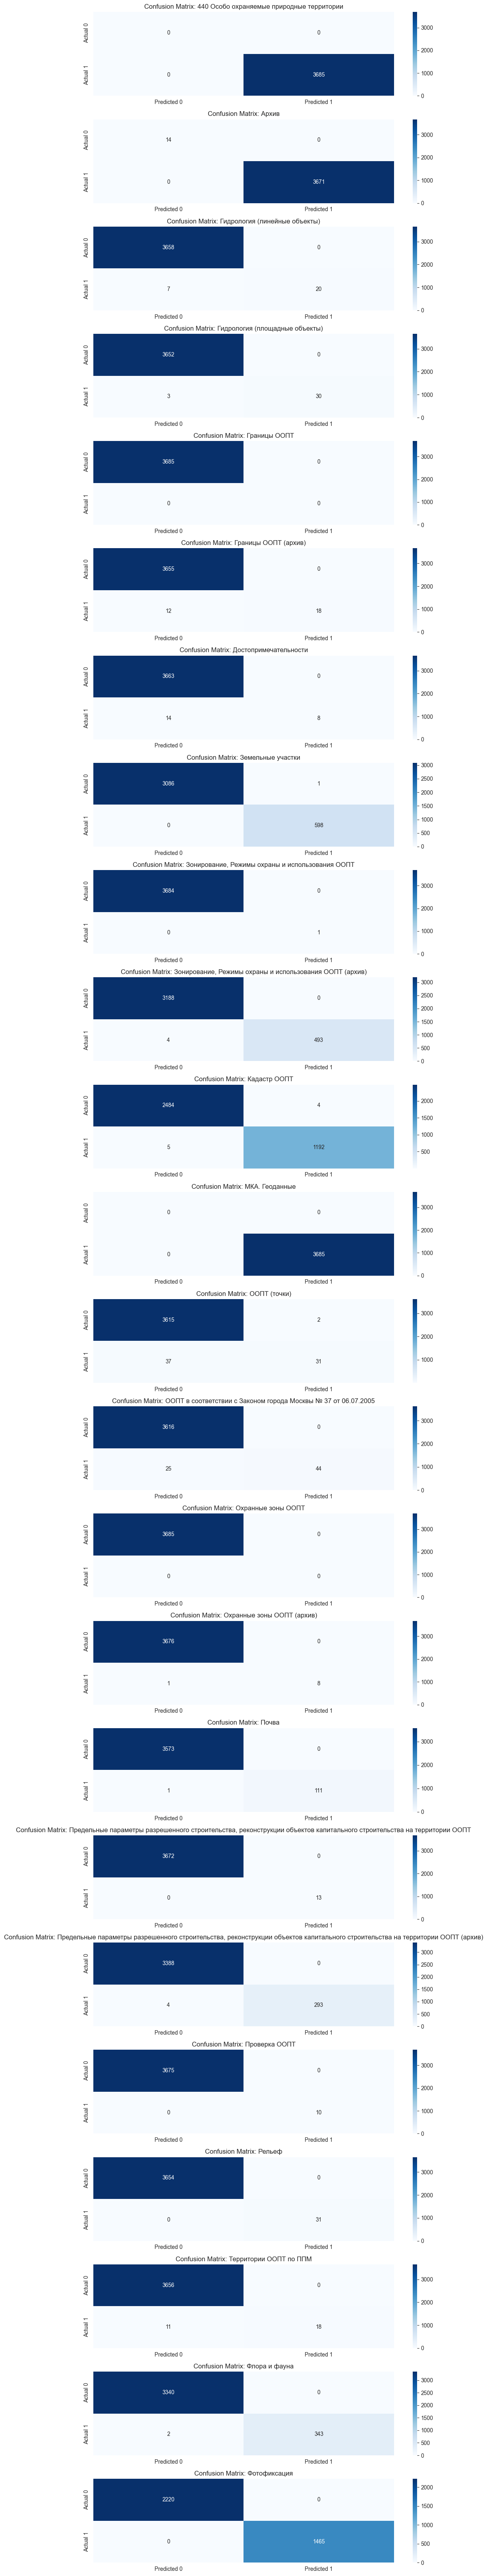

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

# Матрица confusion для каждой метки
mcm = multilabel_confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(len(mlb.classes_), 1, figsize=(10, 65))
axes = axes.ravel()
for i, (matrix, label) in enumerate(zip(mcm, mlb.classes_)):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {label}')
    
plt.tight_layout()
plt.show()

Skipping label 0 - only one class present
Skipping label 4 - only one class present
Skipping label 11 - only one class present
Skipping label 14 - only one class present


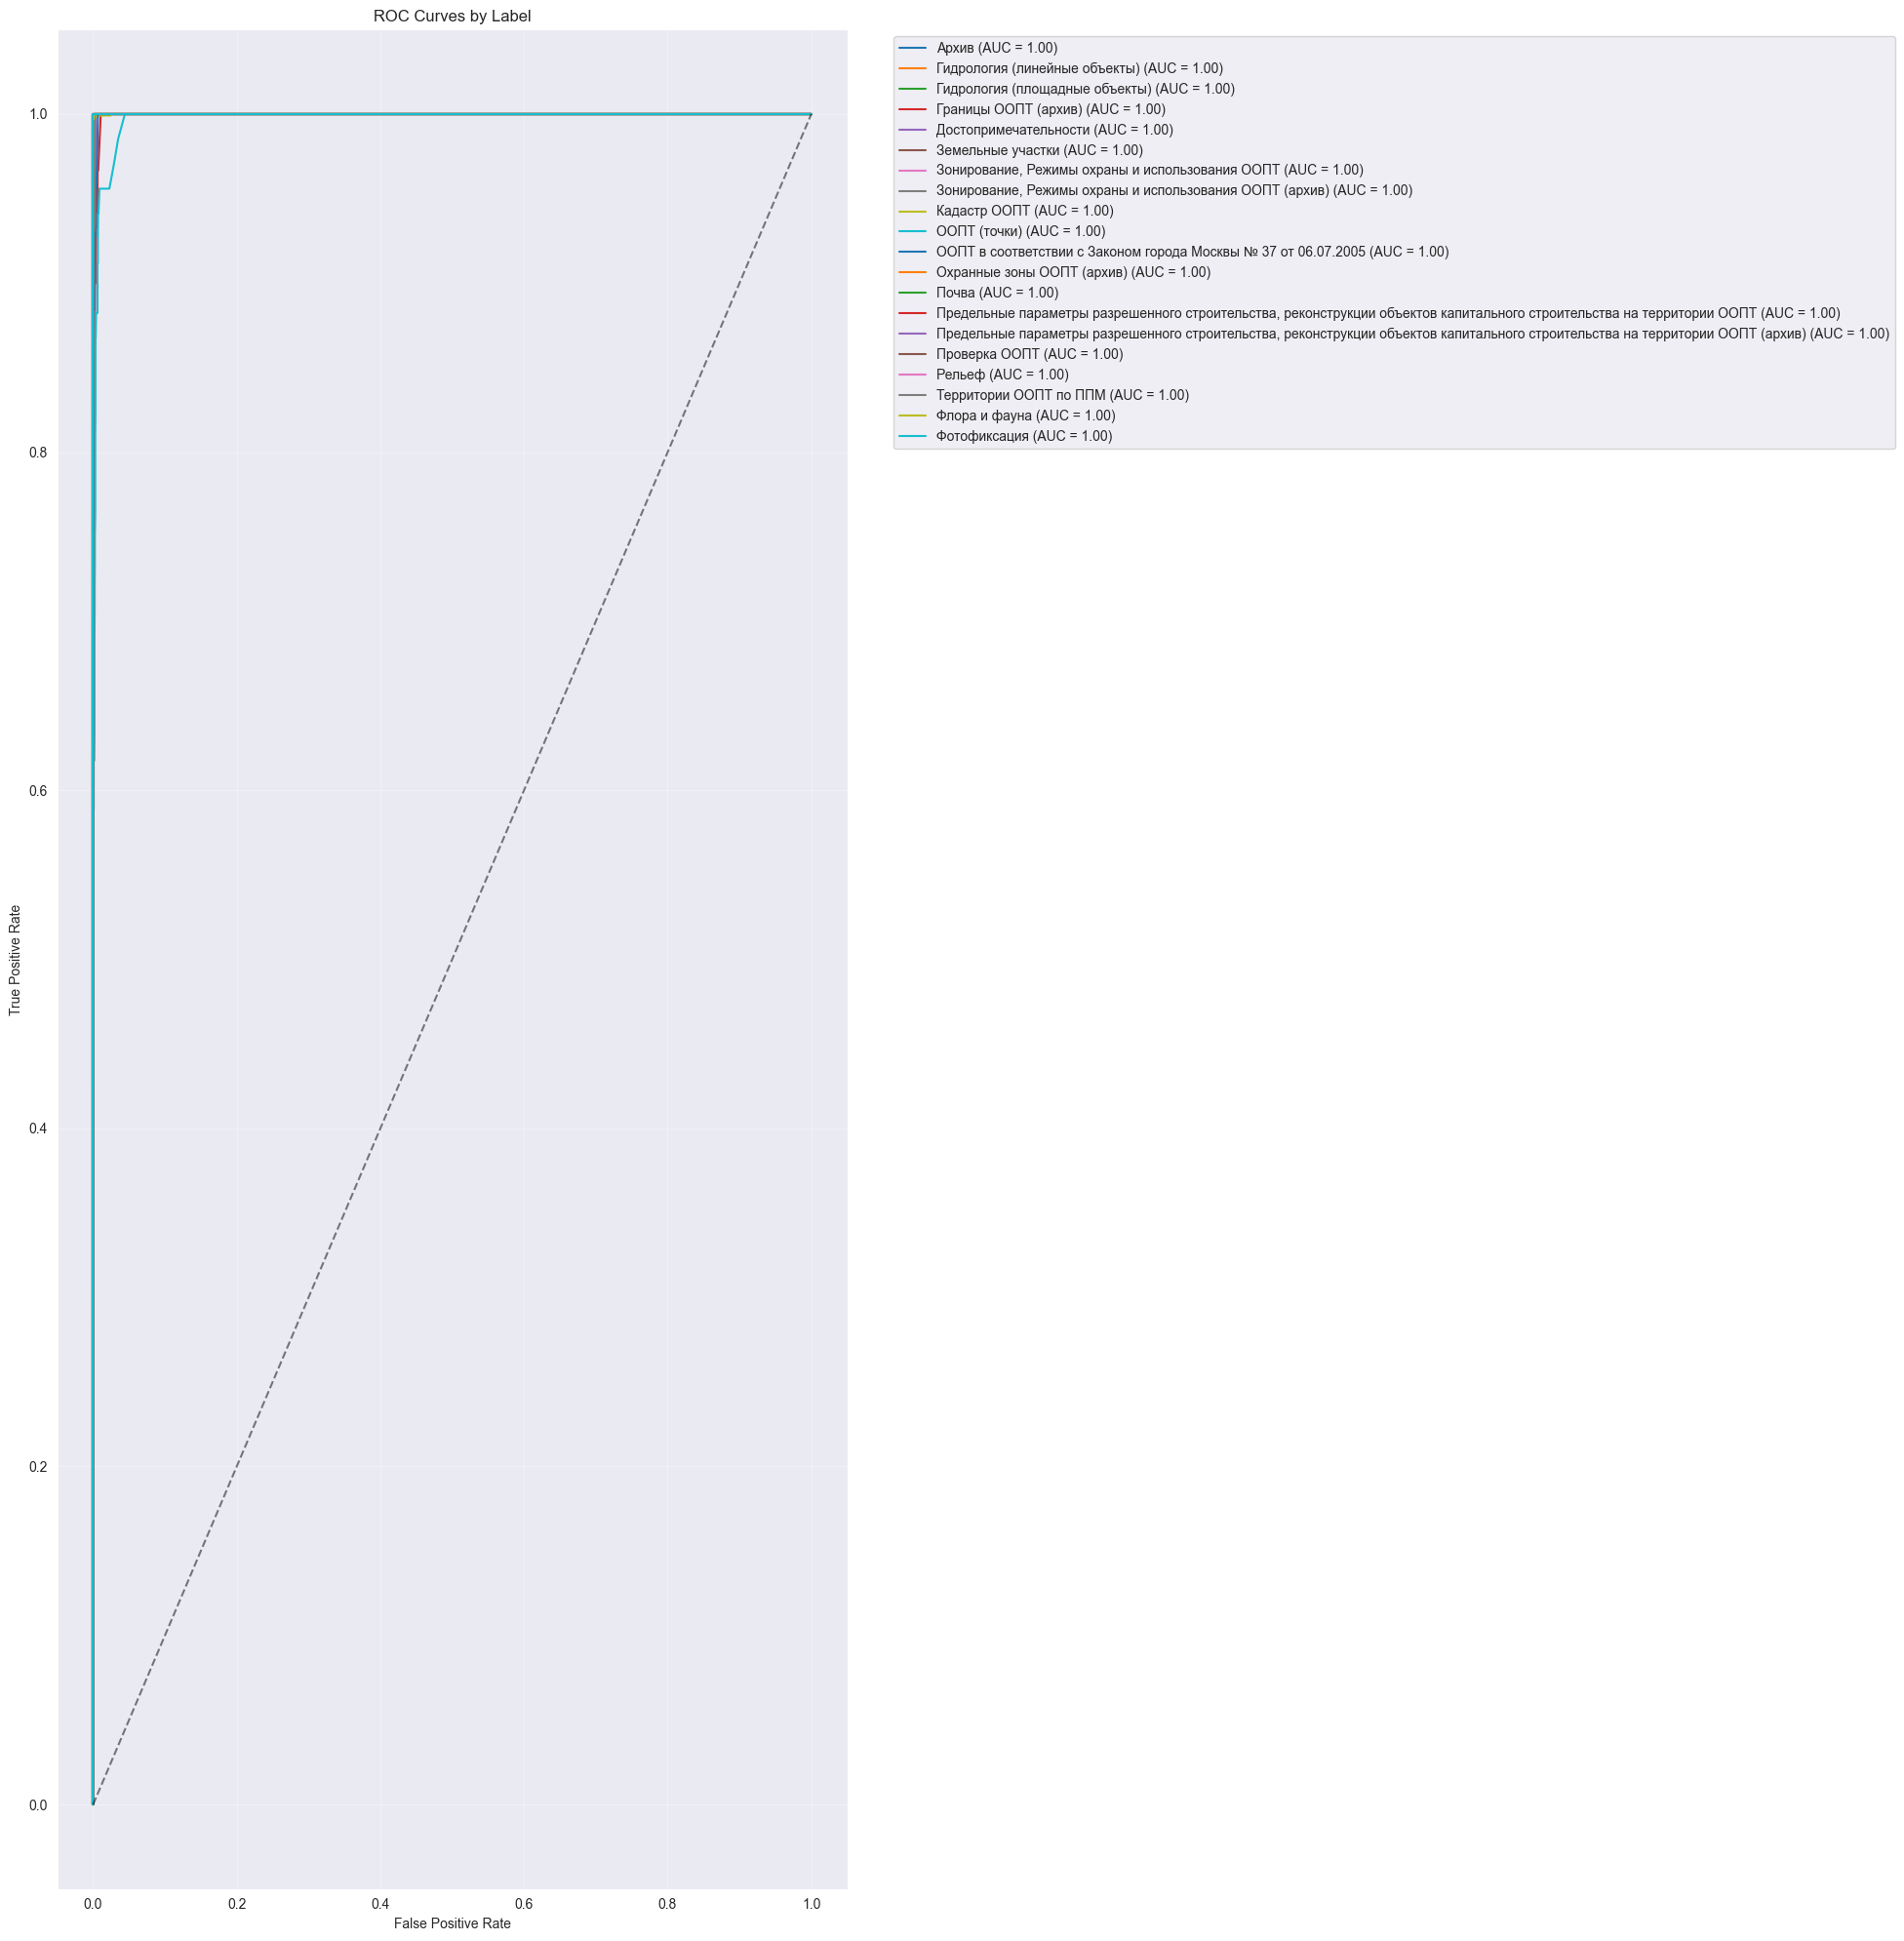

In [106]:
from sklearn.metrics import roc_curve, auc

def plot_multilabel_roc(y_true, y_proba, label_names=None):
    """
    Универсальная функция для построения ROC curves для multilabel
    """
    plt.figure(figsize=(20, 20))
    
    n_labels = y_true.shape[1]
    if label_names is None:
        label_names = [f'Label_{i}' for i in range(n_labels)]
    
    for i in range(n_labels):
        try:
            # Определяем формат вероятностей
            proba = y_proba[i]
            
            if hasattr(proba, 'shape'):
                if proba.shape[1] == 2:
                    proba_positive = proba[:, 1]
                elif proba.shape[1] == 1:
                    proba_positive = proba[:, 0]
                else:
                    proba_positive = proba
            else:
                proba_positive = proba
                
            # Проверяем, есть ли оба класса
            if len(np.unique(y_true[:, i])) < 2:
                print(f"Skipping label {i} - only one class present")
                continue
                
            fpr, tpr, _ = roc_curve(y_true[:, i], proba_positive)
            roc_auc = auc(fpr, tpr)
            
            plt.plot(fpr, tpr, label=f'{label_names[i]} (AUC = {roc_auc:.2f})')
            
        except Exception as e:
            print(f"Error with label {i} ({label_names[i]}): {e}")
            continue
    
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves by Label')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Использование
plot_multilabel_roc(y_test, y_pred_proba, mlb.classes_)

In [107]:
# предсказание
test_text = '1 1 1 Часть территории национального парка \"Лосиный остров\", расположенная в границах города Москвы ППМ № 769-ПП от 11.04.2025 ИК Зона охраны объектов культурного наследия (памятников истории и культуры) народов Российской Федерации 3.1. Коммунальное обслуживание. 3.9. Обеспечение научной деятельности. 5.2. Природно-познавательный туризм. 9.0. Деятельность по особой охране и изучению природы. 9.1. Охрана природных территорий. 9.3. Историко-культурная деятельность. 12.0. Земельные участки (территории) общего пользования - выполнение инженерно-геологических изысканий; - строительство и реконструкция объектов, сооружений и инженерно-технических коммуникаций, связанных с охраной и использованием Национального парка в границах города Москвы, в границах участков размещения объектов капитального строительства; - поддержание в исправном состоянии существующей дорожно-тропиночной сети, сетей наружного освещения, элементов благоустройства; - создание и обустройство зон с информационными площадками Ограничения определяются законодательством Российской Федерации и города Москвы об объектах культурного наследия. 12.032815458365 2323.37880952977 120328.1495391'
cleaned_test_text = clean_text(test_text)
encoded_test_text = model.encode(cleaned_test_text)
# encoded_test_text = np.vstack(encoded_test_text.values)  # или np.array(X.tolist())
test_result = classifier.predict([encoded_test_text])
test_proba = classifier.predict_proba([encoded_test_text])
test_proba

[array([[1.]]),
 array([[0.75, 0.25]]),
 array([[1., 0.]]),
 array([[1., 0.]]),
 array([[1., 0.]]),
 array([[1., 0.]]),
 array([[1., 0.]]),
 array([[0.94, 0.06]]),
 array([[0.32, 0.68]]),
 array([[0.94, 0.06]]),
 array([[0.81, 0.19]]),
 array([[1.]]),
 array([[0.99, 0.01]]),
 array([[1., 0.]]),
 array([[1., 0.]]),
 array([[1., 0.]]),
 array([[1., 0.]]),
 array([[0.99, 0.01]]),
 array([[1., 0.]]),
 array([[0.99, 0.01]]),
 array([[1., 0.]]),
 array([[0.99, 0.01]]),
 array([[1., 0.]]),
 array([[1., 0.]])]

Number of probabilities: 24
Number of labels: 24


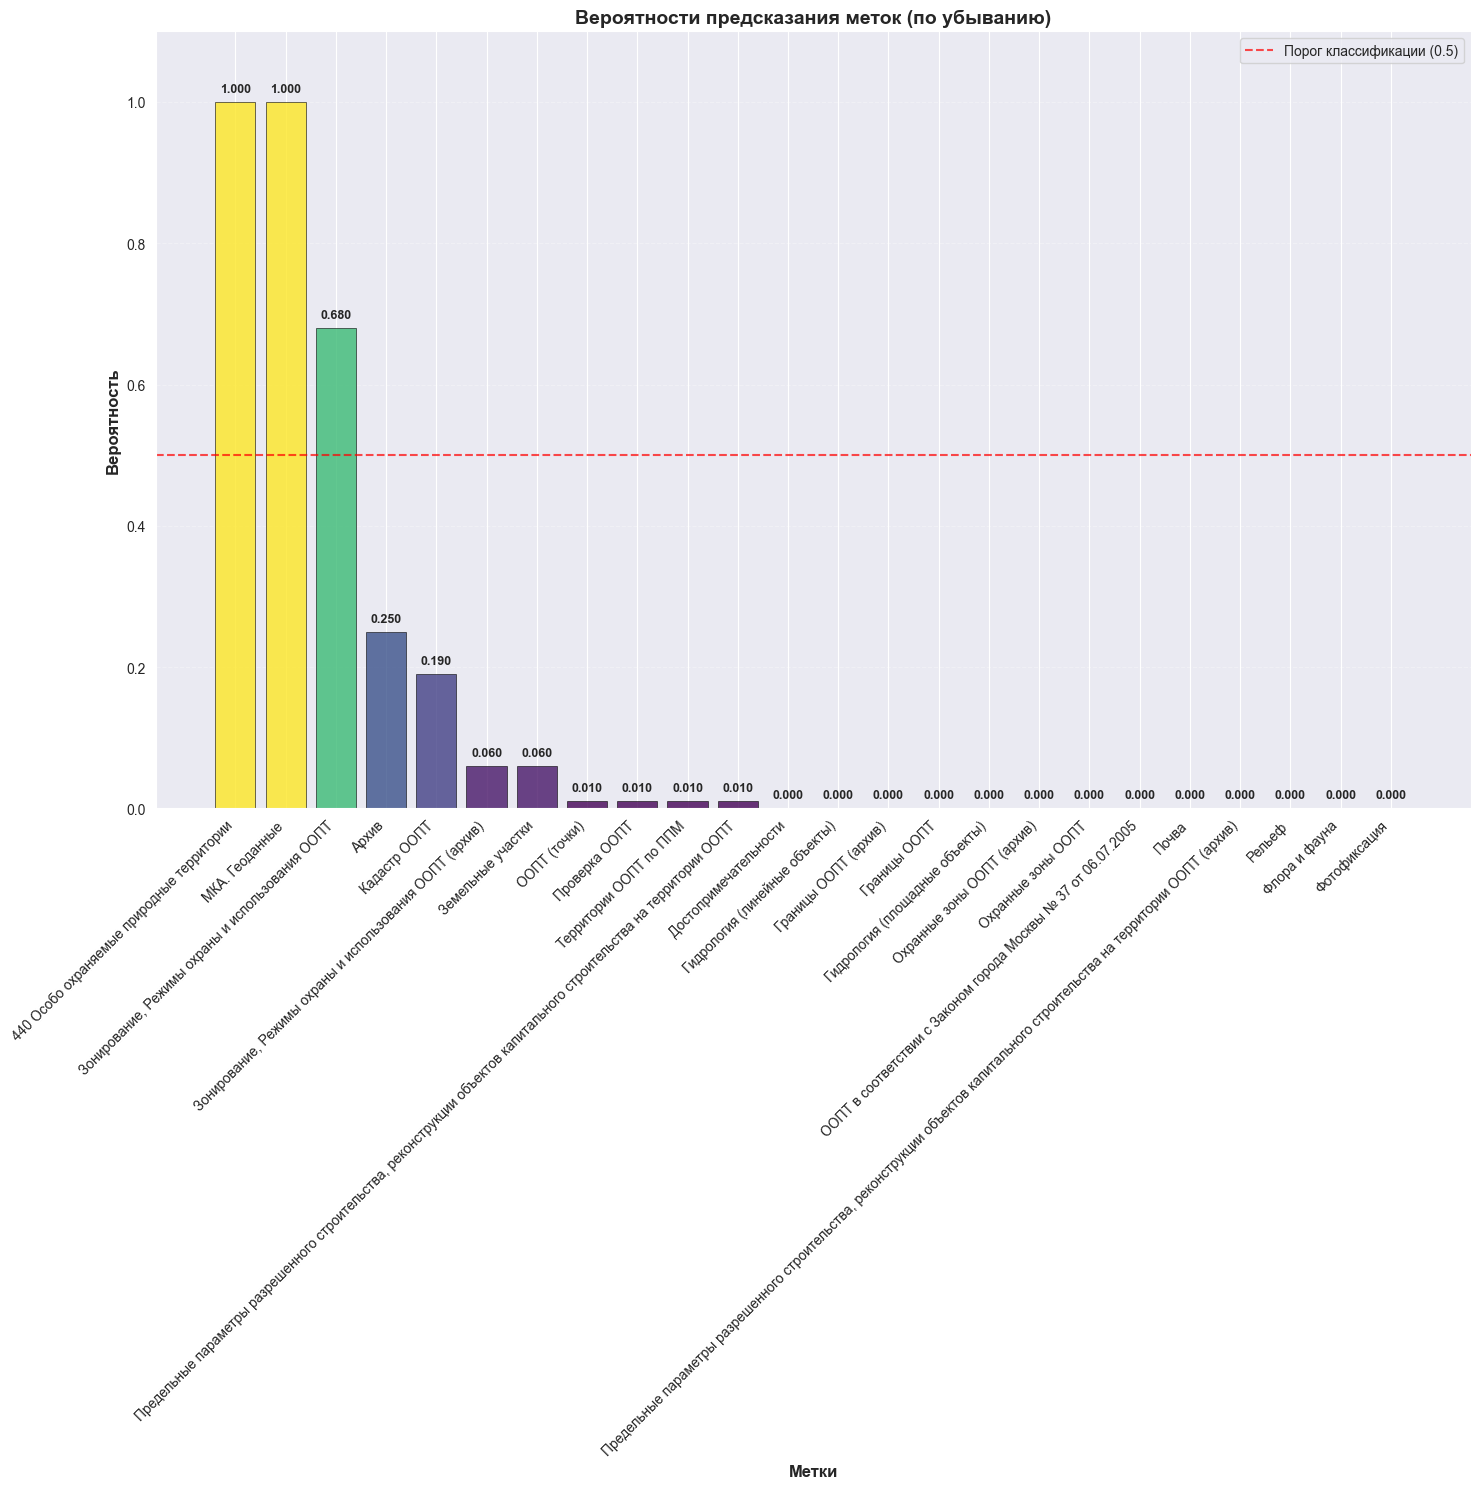

,Label,Probability
0,440 Особо охраняемые природные территории,1.00
11,МКА. Геоданные,1.00
8,"Зонирование, Режимы охраны и использования ООПТ",0.68
1,Архив,0.25
10,Кадастр ООПТ,0.19
9,"Зонирование, Режимы охраны и использования ООПТ (архив)",0.06
7,Земельные участки,0.06
12,ООПТ (точки),0.01
19,Проверка ООПТ,0.01
21,Территории ООПТ по ППМ,0.01


In [114]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Получаем вероятности
test_proba = classifier.predict_proba([encoded_test_text])

# Правильно извлекаем вероятности для каждого класса
proba_list = []
for i, proba in enumerate(test_proba):
    # Проверяем разные возможные форматы
    if hasattr(proba, 'shape'):
        if len(proba.shape) == 2:
            if proba.shape[1] == 2:  # Формат (n_samples, 2)
                proba_list.append(proba[0, 1])  # Берем вероятность положительного класса
            elif proba.shape[1] == 1:  # Формат (n_samples, 1)
                proba_list.append(proba[0, 0])
        elif len(proba.shape) == 1:  # Формат (n_samples,)
            proba_list.append(proba[0])
    else:
        # Если это скаляр или другой формат
        proba_list.append(proba[0] if hasattr(proba, '__len__') else proba)

# Преобразуем в numpy array
proba_array = np.array(proba_list)

print(f"Number of probabilities: {len(proba_array)}")
print(f"Number of labels: {len(mlb.classes_)}")

# Создаем DataFrame и сортируем по убыванию вероятности
proba_df = pd.DataFrame({
    'Label': mlb.classes_,
    'Probability': proba_array
}).sort_values('Probability', ascending=False)

# Создаем график
plt.figure(figsize=(15, 15))
bars = plt.bar(range(len(proba_df)), proba_df['Probability'], 
               color=plt.cm.viridis(proba_df['Probability']),
               alpha=0.8, edgecolor='black', linewidth=0.5)

# Настраиваем внешний вид
plt.xlabel('Метки', fontsize=12, fontweight='bold')
plt.ylabel('Вероятность', fontsize=12, fontweight='bold')
plt.title('Вероятности предсказания меток (по убыванию)', fontsize=14, fontweight='bold')
plt.xticks(range(len(proba_df)), proba_df['Label'], rotation=45, ha='right')
plt.ylim(0, min(1.1, max(proba_df['Probability']) * 1.1))

# Добавляем линию порога классификации
threshold = 0.5
plt.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, 
           label=f'Порог классификации ({threshold})')

# Добавляем значения вероятностей на столбцы
for i, (index, row) in enumerate(proba_df.iterrows()):
    plt.text(i, row['Probability'] + 0.01, f'{row["Probability"]:.3f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

proba_df

In [112]:
# лейблы, вероятность которых больше threshold
proba_df[proba_df['Probability'] >= threshold]

,Label,Probability
0,440 Особо охраняемые природные территории,1.00
11,МКА. Геоданные,1.00
8,"Зонирование, Режимы охраны и использования ООПТ",0.68
